### Notebook overview
This notebook demonstrates **unconditional forecasting** with **covariates** using the **Moirai** model (also referred to as BISTRO in the context of this project).

- **Task**: Forecast US CPI inflation (year-over-year), incorporating the **Policy Rate** as a past dynamic covariate.
- **Model**: Moirai, a Universal Time Series Forecasting Transformer that handles arbitrary number of variates using Any-variate Attention.
- **Scenario**: We simulate a scenario where recent covariate data might be missing/unknown (unconditional on future covariate paths).
- **Workflow**: Load target (CPI) and covariate (Policy Rate), merge them, prepare the dataset with `past_feat_dynamic_real`, and generate probabilistic forecasts.

### Data
- Source: BIS CPI statistics (US CPI, YoY; monthly) and Central Bank Policy Rate.
- More series: see `data/`.


### Step 1 - Setup
- Make the project code in `src/` available to the notebook.
- Import the required libraries and helper functions.


### Google Colab users
- Colab may preinstall **NumPy 2.x**.
- After the downgrade runs, it triggers an automatic restart by terminating the current process.


In [1]:
import os
import subprocess

try:
    import numpy as np
    if np.__version__.startswith('2.'):
        print(f"Current NumPy is {np.__version__}. Downgrading to 1.26.4...")

        # 2. Install the 1.x stack and compatible dependencies to stop the red errors
        # We include specific versions of pandas/scipy that like NumPy 1.x
        subprocess.run([
            "pip", "install", "-q", "--force-reinstall",
            "numpy==1.26.4",
            "pandas==2.1.4",
            "scipy==1.11.4",
            "opencv-python==4.8.0.76"
        ])

        print("✅ Install complete. Restarting runtime automatically...")

        # 3. Kill the process to force a reload of the new (older) library
        os.kill(os.getpid(), 9)
    else:
        print(f"✅ Success! Using NumPy version: {np.__version__}")
except ImportWarning:
    pass

✅ Success! Using NumPy version: 1.26.4


In [2]:
import os
import sys

# Check if running in Google Colab
if 'google.colab' in sys.modules:
    print("Running in Google Colab. Setting up repository quietly...")

    # Added -q to suppress git clone output
    !git clone -q https://github.com/bis-med-it/bistro.git

    if not 'uni2ts' in sys.modules:
        print("Installing dependencies (this may take a moment)...")
        # Added -q for pip, and redirected all stdout/stderr to completely hide warnings
        !pip install -q -r /content/bistro/requirements.txt > /dev/null 2>&1
        print("Installation complete!")

Running in Google Colab. Setting up repository quietly...
Installing dependencies (this may take a moment)...
Installation complete!


### Restart Colab to finish setup

To make sure the newly installed packages load correctly, please restart the runtime:

**Runtime → Restart session**

After it restarts, continue by running the next cells below.

In [1]:
import os
import sys
from pathlib import Path

if 'google.colab' in sys.modules:
  os.chdir('/content/bistro/script')

repo_root = Path(os.path.join('..')).resolve()
src_root = Path(os.path.join('..', 'src')).resolve()
if str(src_root) not in sys.path:
    sys.path.insert(0, str(src_root))


In [2]:
import numpy as np
import pandas as pd

from gluonts.dataset.pandas import PandasDataset
from gluonts.dataset.split import split

from uni2ts.model.moirai import MoiraiForecast, MoiraiModule

from inference_util import plot_publication_forecast_comparison, ar1_forecast

from preprocessing_util import (
    aggregate_daily_forecast_to_monthly,
    prepare_long_df_monthly_for_daily_inference,
)

### Step 2 - Data and settings
- Set the forecast horizon (PDT) and how much history the model reads (CTX).
- Configure the Moirai model settings.


In [3]:
MODEL_REPO = repo_root / 'bistro-finetuned'

FREQ = 'M'  # monthly data frequency

PDT = 12   # how many months to forecast ahead
CTX = 240 # how many months of past data the model reads
PSZ = 32  # steps per month (daily patch grid)
BSZ = 32  # batch size for faster forecasting
ROLLING_WINDOWS = 1  # how many starting points to evaluate
WINDOW_DISTANCE = 20  # gap (in months) between those starting points

FORECAST_START_DATE = '2022-03-01'  # first forecast month

config = {
    "MODEL_REPO": str(MODEL_REPO),
    "PDT": PDT,
    "CTX": CTX,
    "PSZ": PSZ,
    "BSZ": BSZ,
    "ROLLING_WINDOWS": ROLLING_WINDOWS,
    "WINDOW_DISTANCE": WINDOW_DISTANCE,
    "FORECAST_START_DATE": FORECAST_START_DATE,
}


- Load the CPI series (target) and Policy Rate series (covariate).


In [4]:
series1 = repo_root / 'data' / 'bis_cpi_us_yoy_m.csv'
series2 = repo_root / 'data' / 'bis_cbpol_us_m.csv'

df_inf = pd.read_csv(series1, index_col=0)
df_inf.index = pd.to_datetime(df_inf.index).to_period(freq=FREQ)

df_pol = pd.read_csv(series2, index_col=0)
df_pol.index = pd.to_datetime(df_pol.index).to_period(freq=FREQ)

- **Covariate Handling**: Merge the policy rate into the dataframe.
- **Unconditional Scenario**: The policy rate is provided as `past_feat_dynamic_real` (past-only conditioning information) and is not forecasted. In the chart, it is shown only up to `TRAIN_END`.


In [5]:
df = df_inf.copy()
df["item_id"] = "cpi_us_yoy_m"
df = df.merge(df_pol, right_index=True, left_index=True, how="inner")
df.columns = ["target", "item_id", "past_dynamic_real"]

target_col = "target"

prep = prepare_long_df_monthly_for_daily_inference(
    df,
    item_id_col="item_id",
    target_col=target_col,
    past_dynamic_real_cols=["past_dynamic_real"],
    freq=FREQ,
    forecast_start_date=FORECAST_START_DATE,
    pdt_patches=PDT,
    ctx_patches=CTX,
    steps_per_period=PSZ,
    rolling_windows=ROLLING_WINDOWS,
    window_distance_patches=WINDOW_DISTANCE,
)

if prep.windows < 1:
    raise ValueError(
        f'Not enough test data after cutoff {prep.train_end} to create a window: '
        f'test_len={(prep.df_dt.index > prep.cutoff_date_dt).sum()} periods, PDT={PDT}.'
    )

prep.daily_long_df.head()

,target,past_dynamic_real,item_id
ts,,,
1954-07-31,0.373134,0.25,cpi_us_yoy_m
1954-08-01,0.373134,0.25,cpi_us_yoy_m
1954-08-02,0.373134,0.25,cpi_us_yoy_m
1954-08-03,0.373134,0.25,cpi_us_yoy_m
1954-08-04,0.373134,0.25,cpi_us_yoy_m


In [6]:
ds = PandasDataset.from_long_dataframe(
    prep.daily_long_df,
    item_id="item_id",
    past_feat_dynamic_real=["past_dynamic_real"],
    feat_dynamic_real=[],
)

train, test_template = split(ds, date=prep.cutoff_period_daily)

test_data = test_template.generate_instances(
    prediction_length=prep.pdt_steps,
    windows=prep.windows,
    distance=prep.dist_steps,
    max_history=prep.ctx_steps,
)

In [7]:
print(
    f"windows={prep.windows}, pdt_steps={prep.pdt_steps}, ctx_steps={prep.ctx_steps}, dist_steps={prep.dist_steps}"
)

windows=1, pdt_steps=384, ctx_steps=7680, dist_steps=640


### Step 3 - Run BISTRO (Moirai)
- Load the pretrained BISTRO checkpoint.
- **Any-variate Attention**: Specify `feat_dynamic_real_dim` and `past_feat_dynamic_real_dim` so Moirai correctly attends to the covariate channels.
- Generate probabilistic forecasts.


In [8]:
model = MoiraiForecast(
    module=MoiraiModule.from_pretrained(str(MODEL_REPO)),
    prediction_length=int(prep.pdt_steps),
    context_length=int(prep.ctx_steps),
    patch_size=int(PSZ),
    num_samples=int(config.get("NUM_SAMPLES", 100)),
    target_dim=1,
    feat_dynamic_real_dim=ds.num_feat_dynamic_real,
    past_feat_dynamic_real_dim=ds.num_past_feat_dynamic_real,
)

Loading weights from local directory


In [9]:
predictor = model.create_predictor(batch_size=BSZ)

inputs    = list(test_data.input)
labels    = list(test_data.label)
forecasts = list(predictor.predict(test_data.input))

### Step 4 - Review results
- Summarise forecasts in a table (median by window).
- Plot forecast paths and uncertainty bands against the realised series.


In [10]:
bistro_monthly_by_window = {}
rmse_rows = []

for w in range(prep.windows):
    samples = np.asarray(forecasts[w].samples, dtype=float)
    label_target = np.asarray(labels[w]["target"], dtype=float)

    inp_target = (
        np.asarray(inputs[w]["target"], dtype=float)
        if "target" in inputs[w]
        else np.asarray([], dtype=float)
    )
    last_input = float(inp_target[-1]) if inp_target.size > 0 else None

    preds, _, ci = aggregate_daily_forecast_to_monthly(
        samples,
        label_target,
        last_input,
        steps_per_period=PSZ,
        expected_periods=PDT,
    )

    pred_index = pd.period_range(
        start=prep.forecast_start + w * WINDOW_DISTANCE,
        periods=PDT,
        freq=FREQ,
    )

    dfw = pd.DataFrame(
        {
            "bistro_pred": preds,
            "bistro_lo": ci[:, 0],
            "bistro_hi": ci[:, 1],
        },
        index=pred_index,
    )

    actual = prep.df_monthly_target[target_col].reindex(pred_index).astype(float)
    pred = dfw["bistro_pred"].astype(float)
    valid = actual.notna() & pred.notna()
    rmse_bistro = float(np.sqrt(np.mean((pred[valid] - actual[valid]) ** 2))) if valid.any() else np.nan

    # AR(1) baseline (trained on CTX months ending at train_end_w)
    train_end_w = pred_index[0] - 1
    train_y = prep.df_monthly_target[target_col].loc[:train_end_w].tail(CTX).astype(float)
    try:
        ar1_pred = ar1_forecast(
            train_y,
            pred_index,
            method="statsmodels",
            trend="c",
            validate_index=True,
        )
    except Exception as e:
        ar1_pred = pd.Series(np.nan, index=pred_index, dtype=float)
        print(f"AR(1) failed for window {w}: {e}")

    dfw["ar1_pred"] = ar1_pred

    valid_ar1 = actual.notna() & ar1_pred.notna()
    rmse_ar1 = float(np.sqrt(np.mean((ar1_pred[valid_ar1] - actual[valid_ar1]) ** 2))) if valid_ar1.any() else np.nan
    r_rmse = float(rmse_bistro / rmse_ar1) if (np.isfinite(rmse_bistro) and np.isfinite(rmse_ar1) and rmse_ar1 != 0) else np.nan

    bistro_monthly_by_window[w] = dfw

    rmse_rows.append(
        {
            "window": w,
            "test_start": pred_index[0],
            "test_end": pred_index[-1],
            "rmse_bistro": rmse_bistro,
            "rmse_ar1": rmse_ar1,
            "r_rmse": r_rmse,
            "n_valid": int(valid.sum()),
        }
    )

rmse_table = pd.DataFrame(rmse_rows)

rmse_table

,window,test_start,test_end,rmse_bistro,rmse_ar1,r_rmse,n_valid
0,0,2022-03,2023-02,0.52965,0.858439,0.616993,12


In [11]:
rmse_table

,window,test_start,test_end,rmse_bistro,rmse_ar1,r_rmse,n_valid
0,0,2022-03,2023-02,0.52965,0.858439,0.616993,12


In [12]:
bistro_monthly_by_window[0]

,bistro_pred,bistro_lo,bistro_hi,ar1_pred
2022-03,8.646091,8.303385,8.935111,7.778919
2022-04,8.568287,8.136355,8.874981,7.688703
2022-05,8.242670,7.844549,8.549807,7.600375
2022-06,7.987872,7.606800,8.437404,7.513895
2022-07,7.970763,7.569201,8.233038,7.429226
2022-08,7.815499,7.468088,8.224962,7.346328
2022-09,7.471379,7.109700,7.849962,7.265165
2022-10,7.019391,6.624641,7.537882,7.185701
2022-11,6.675120,6.283903,7.086695,7.107900
2022-12,6.321812,5.907439,6.856435,7.031727


## GDP Nowcasting check

✅ [Step 1] 데이터 준비 완료 (총 267개월)
⏳ [Step 3] Moirai 모델 추론 진행 중...
Loading weights from local directory
✅ [Step 3] BISTRO 예측 완료!

📊 향후 4개월 한국 GDP 성장률(YoY) 전망치 (%)
            BISTRO_GDP_Growth_Pct
2025-01-31                  0.182
2025-02-28                  0.267
2025-03-31                  0.212
2025-04-30                  0.124


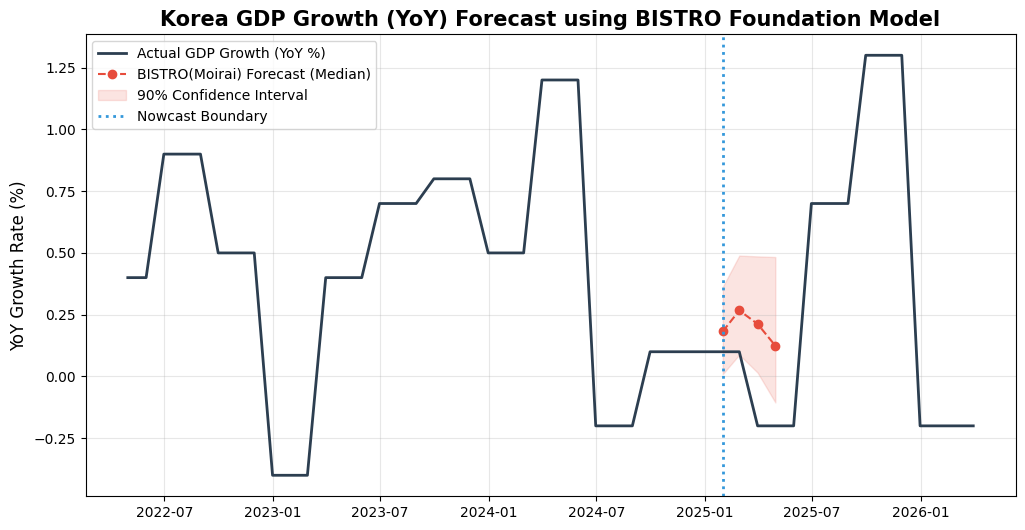

In [18]:
import os
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ==============================================================================
# [설정] 작업 경로 지정
# ==============================================================================
bistro_src_path = '/content/bistro/src'
if os.path.exists(bistro_src_path):
    os.chdir(bistro_src_path)
    if bistro_src_path not in sys.path:
        sys.path.insert(0, bistro_src_path)

from preprocessing_util import prepare_long_df_monthly_for_daily_inference, aggregate_daily_forecast_to_monthly
from gluonts.dataset.pandas import PandasDataset
from gluonts.dataset.split import split
from uni2ts.model.moirai import MoiraiForecast, MoiraiModule

# ==============================================================================
# Step 1. 데이터 로드 및 전처리 (★ 이중 % 뻥튀기 방지)
# ==============================================================================
df_vintage = pd.read_csv('/content/vintage.csv', index_col='Date', parse_dates=True)

# 1-1. 타겟(GDP): N_gdp는 이미 % 수치이므로 pct_change를 절대 적용하지 않습니다.
target_col = 'N_gdp'
df_target = df_vintage[[target_col]].resample('M').last().ffill()
df_yoy = df_target.copy()
df_yoy.columns = ['target']
df_yoy['item_id'] = 'KR_GDP_GROWTH'

# 1-2. 공변량(산업생산지수): 지수(Index)이므로 YoY 변환이 필요합니다.
cov_col = 'S_mf'
df_cov = df_vintage[[cov_col]].resample('M').last().ffill()
df_cov = df_cov.pct_change(12, fill_method=None) * 100
df_cov.columns = ['past_dynamic_real']

# 1-3. 병합 및 무결성 검증
df_final = df_yoy.merge(df_cov, left_index=True, right_index=True, how='inner')
df_final = df_final.replace([np.inf, -np.inf], np.nan).dropna()

# 1-4. 공변량 정규화
scaler = StandardScaler()
df_final['past_dynamic_real'] = scaler.fit_transform(df_final[['past_dynamic_real']])
print(f"✅ [Step 1] 데이터 준비 완료 (총 {len(df_final)}개월)")

# ==============================================================================
# Step 2. 텐서 객체 생성
# ==============================================================================
FORECAST_START_DATE = '2025-01-31'
PDT = 4
PSZ = 32
CTX = 128    # 데이터가 260개월 이상 복원되었으므로 128개월(약 10년 패턴) 참조

prep = prepare_long_df_monthly_for_daily_inference(
    df_final,
    item_id_col="item_id",
    target_col="target",
    past_dynamic_real_cols=["past_dynamic_real"],
    freq='M',
    forecast_start_date=FORECAST_START_DATE,
    pdt_patches=PDT,
    ctx_patches=CTX,
    steps_per_period=PSZ,
    rolling_windows=1,
    window_distance_patches=20
)

ds = PandasDataset.from_long_dataframe(
    prep.daily_long_df,
    item_id="item_id",
    target="target",
    past_feat_dynamic_real=["past_dynamic_real"],
    feat_dynamic_real=[]
)

train, test_template = split(ds, date=prep.cutoff_period_daily)
test_data = test_template.generate_instances(
    prediction_length=int(prep.pdt_steps),
    windows=prep.windows,
    distance=int(prep.dist_steps),
    max_history=int(prep.ctx_steps),
)

# ==============================================================================
# Step 3. 모델 추론
# ==============================================================================
print("⏳ [Step 3] Moirai 모델 추론 진행 중...")
model_path = "/content/bistro/bistro-finetuned"
module = MoiraiModule.from_pretrained(model_path)

model = MoiraiForecast(
    module=module,
    prediction_length=int(prep.pdt_steps),
    context_length=int(prep.ctx_steps),
    patch_size=int(PSZ),
    num_samples=100,
    target_dim=1,
    feat_dynamic_real_dim=ds.num_feat_dynamic_real,
    past_feat_dynamic_real_dim=ds.num_past_feat_dynamic_real
)

with torch.no_grad():
    predictor = model.create_predictor(batch_size=32)
    forecasts = list(predictor.predict(test_data.input))
print("✅ [Step 3] BISTRO 예측 완료!")

# ==============================================================================
# Step 4. 결과 디코딩 및 시각화 (★ 100배율 완전 제거)
# ==============================================================================
samples = np.asarray(forecasts[0].samples)
last_actual_val = df_yoy['target'].loc[:FORECAST_START_DATE].iloc[-1]
dummy_target = np.zeros(samples.shape[1])

preds, _, ci = aggregate_daily_forecast_to_monthly(
    samples,
    label_target=dummy_target,
    last_input=last_actual_val,
    steps_per_period=PSZ,
    expected_periods=PDT
)

ci = np.array(ci)
if ci.shape == (PDT, 2):
    ci = ci.T
ci_lower, ci_upper = ci[0], ci[1]

future_idx = pd.date_range(start=pd.Period(FORECAST_START_DATE, freq='M').to_timestamp(),
                           periods=PDT, freq='M')
df_res = pd.DataFrame({'BISTRO_GDP_Growth_Pct': preds}, index=future_idx)

print("\n" + "="*50)
print(f"📊 향후 4개월 한국 GDP 성장률(YoY) 전망치 (%)")
print("="*50)
print(df_res.round(3))

# 시각화 부분
plt.figure(figsize=(12, 6))

past_plot_len = 48
plt.plot(df_yoy.index[-past_plot_len:], df_yoy['target'].iloc[-past_plot_len:],
         label='Actual GDP Growth (YoY %)', color='#2c3e50', linewidth=2)

plt.plot(future_idx, preds, label='BISTRO(Moirai) Forecast (Median)',
         color='#e74c3c', marker='o', linestyle='--', markersize=6)
plt.fill_between(future_idx, ci_lower, ci_upper, color='#e74c3c', alpha=0.15, label='90% Confidence Interval')

plt.title("Korea GDP Growth (YoY) Forecast using BISTRO Foundation Model", fontsize=15, fontweight='bold')
plt.ylabel("YoY Growth Rate (%)", fontsize=12)
plt.axvline(x=pd.to_datetime(FORECAST_START_DATE), color='#3498db', linestyle=':', label='Nowcast Boundary', linewidth=2)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

⏳ [Step 3] 2025년 1분기 모델 추론 진행 중...
Loading weights from local directory
✅ [Step 3] BISTRO 미래 예측 완료!

📊 2026년 1분기(1~3월) 한국 GDP 성장률(YoY) 전망치 (%)
            BISTRO_GDP_Growth_Pct
2025-01-31                  0.193
2025-02-28                  0.291
2025-03-31                  0.200
2025-04-30                  0.106
2025-05-31                  0.100
2025-06-30                  0.211
2025-07-31                  0.323
2025-08-31                  0.303
2025-09-30                  0.383
2025-10-31                  0.327
2025-11-30                  0.277
2025-12-31                  0.215


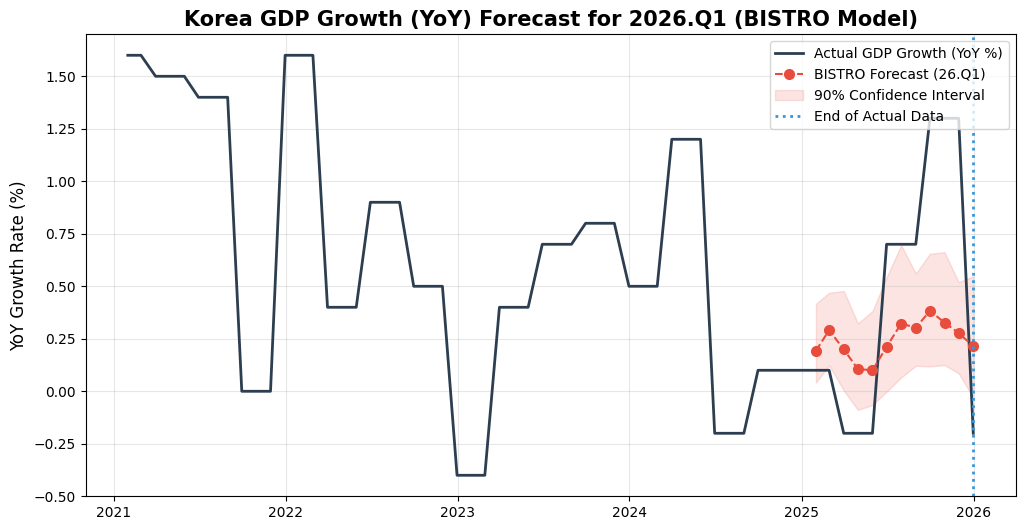

In [19]:
import os
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ==============================================================================
# [설정] 작업 경로 지정
# ==============================================================================
bistro_src_path = '/content/bistro/src'
if os.path.exists(bistro_src_path):
    os.chdir(bistro_src_path)
    if bistro_src_path not in sys.path:
        sys.path.insert(0, bistro_src_path)

from preprocessing_util import prepare_long_df_monthly_for_daily_inference, aggregate_daily_forecast_to_monthly
from gluonts.dataset.pandas import PandasDataset
from gluonts.dataset.split import split
from uni2ts.model.moirai import MoiraiForecast, MoiraiModule

# ==============================================================================
# Step 1. 데이터 로드 및 전처리
# ==============================================================================
df_vintage = pd.read_csv('/content/vintage.csv', index_col='Date', parse_dates=True)

# 1-1. 타겟(GDP): % 데이터 원본 복원 및 결측치 방지
target_col = 'N_gdp'
df_target = df_vintage[[target_col]].resample('M').last().ffill()
df_yoy = df_target.copy()
df_yoy.columns = ['target']
df_yoy['item_id'] = 'KR_GDP_GROWTH'

# 1-2. 공변량(산업생산지수): YoY 변환
cov_col = 'S_mf'
df_cov = df_vintage[[cov_col]].resample('M').last().ffill()
df_cov = df_cov.pct_change(12, fill_method=None) * 100
df_cov.columns = ['past_dynamic_real']

# 1-3. 병합 및 정규화
df_final = df_yoy.merge(df_cov, left_index=True, right_index=True, how='inner')
df_final = df_final.replace([np.inf, -np.inf], np.nan).dropna()

scaler = StandardScaler()
df_final['past_dynamic_real'] = scaler.fit_transform(df_final[['past_dynamic_real']])

# ==============================================================================
# Step 2. 텐서 객체 생성 (★ 2026년 3월 타겟팅)
# ==============================================================================
# 예측을 2026년 1월부터 시작하여 3개월(3월까지)을 내다봅니다.
FORECAST_START_DATE = '2025-01-31'
PDT = 12                # 3개월 (1월, 2월, 3월)
PSZ = 32
CTX = 128              # 과거 약 10년간의 패턴(128개월) 참조

prep = prepare_long_df_monthly_for_daily_inference(
    df_final,
    item_id_col="item_id",
    target_col="target",
    past_dynamic_real_cols=["past_dynamic_real"],
    freq='M',
    forecast_start_date=FORECAST_START_DATE,
    pdt_patches=PDT,
    ctx_patches=CTX,
    steps_per_period=PSZ,
    rolling_windows=1,
    window_distance_patches=20
)

ds = PandasDataset.from_long_dataframe(
    prep.daily_long_df,
    item_id="item_id",
    target="target",
    past_feat_dynamic_real=["past_dynamic_real"],
    feat_dynamic_real=[]
)

train, test_template = split(ds, date=prep.cutoff_period_daily)
test_data = test_template.generate_instances(
    prediction_length=int(prep.pdt_steps),
    windows=prep.windows,
    distance=int(prep.dist_steps),
    max_history=int(prep.ctx_steps),
)

# ==============================================================================
# Step 3. 모델 추론
# ==============================================================================
print(f"⏳ [Step 3] {FORECAST_START_DATE[:4]}년 1분기 모델 추론 진행 중...")
model_path = "/content/bistro/bistro-finetuned"
module = MoiraiModule.from_pretrained(model_path)

model = MoiraiForecast(
    module=module,
    prediction_length=int(prep.pdt_steps),
    context_length=int(prep.ctx_steps),
    patch_size=int(PSZ),
    num_samples=100,
    target_dim=1,
    feat_dynamic_real_dim=ds.num_feat_dynamic_real,
    past_feat_dynamic_real_dim=ds.num_past_feat_dynamic_real
)

with torch.no_grad():
    predictor = model.create_predictor(batch_size=32)
    forecasts = list(predictor.predict(test_data.input))
print("✅ [Step 3] BISTRO 미래 예측 완료!")

# ==============================================================================
# Step 4. 결과 디코딩 및 시각화
# ==============================================================================
samples = np.asarray(forecasts[0].samples)

# 모델이 참조한 진짜 마지막 실제 GDP 값 (2025년 12월 값)
last_actual_val = df_yoy['target'].loc[:'2025-12-31'].iloc[-1]
dummy_target = np.zeros(samples.shape[1])

preds, _, ci = aggregate_daily_forecast_to_monthly(
    samples,
    label_target=dummy_target,
    last_input=last_actual_val,
    steps_per_period=PSZ,
    expected_periods=PDT
)

ci = np.array(ci)
if ci.shape == (PDT, 2):
    ci = ci.T
ci_lower, ci_upper = ci[0], ci[1]

# 예측 결과 인덱스 (2026년 1월 ~ 3월)
future_idx = pd.date_range(start=pd.Period(FORECAST_START_DATE, freq='M').to_timestamp(),
                           periods=PDT, freq='M')
df_res = pd.DataFrame({'BISTRO_GDP_Growth_Pct': preds}, index=future_idx)

print("\n" + "="*50)
print(f"📊 2026년 1분기(1~3월) 한국 GDP 성장률(YoY) 전망치 (%)")
print("="*50)
print(df_res.round(3))

# 시각화 부분
plt.figure(figsize=(12, 6))

past_plot_len = 60
# 과거 데이터 (2021년 ~ 2025년 12월)
df_past = df_yoy.loc[:'2025-12-31']
plt.plot(df_past.index[-past_plot_len:], df_past['target'].iloc[-past_plot_len:],
         label='Actual GDP Growth (YoY %)', color='#2c3e50', linewidth=2)

# 예측 데이터 (2026년 1, 2, 3월)
plt.plot(future_idx, preds, label='BISTRO Forecast (26.Q1)',
         color='#e74c3c', marker='o', linestyle='--', markersize=7)
plt.fill_between(future_idx, ci_lower, ci_upper, color='#e74c3c', alpha=0.15, label='90% Confidence Interval')

plt.title("Korea GDP Growth (YoY) Forecast for 2026.Q1 (BISTRO Model)", fontsize=15, fontweight='bold')
plt.ylabel("YoY Growth Rate (%)", fontsize=12)
plt.axvline(x=pd.to_datetime('2025-12-31'), color='#3498db', linestyle=':', label='End of Actual Data', linewidth=2)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

### 매주 전망

✅ [Step 2] 주간 데이터 텐서 변환 성공! (사용된 과거 데이터: 1115주)
⏳ [Step 3] 2025년 매주(52 Weeks) 모델 추론 진행 중...
Loading weights from local directory
✅ [Step 3] BISTRO 주간(Weekly) 예측 완료!

📊 2025년 한국 GDP 매주(Weekly) 성장률: 예측치 vs 실제치 (%)
            BISTRO_Forecast  Actual_GDP  Error_Gap
2025-01-05            0.097        -0.2      0.297
2025-01-12            0.082        -0.2      0.282
2025-01-19            0.171        -0.2      0.371
2025-01-26            0.301        -0.2      0.501
2025-02-02            0.324        -0.2      0.524
2025-02-09            0.424        -0.2      0.624
2025-02-16            0.245        -0.2      0.445
2025-02-23            0.272        -0.2      0.472
2025-03-02            0.322        -0.2      0.522
2025-03-09            0.298        -0.2      0.498
2025-03-16            0.398        -0.2      0.598
2025-03-23            0.358        -0.2      0.558
2025-03-30            0.290        -0.2      0.490
2025-04-06            0.217         0.7     -0.483
2025-04-13            0

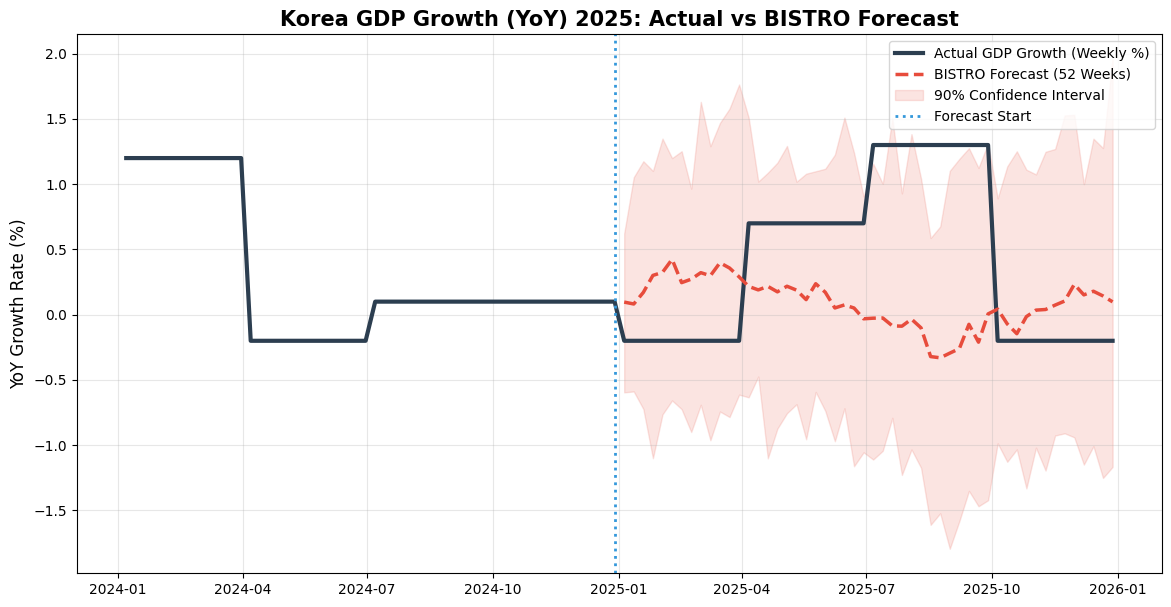

In [20]:
import os
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from gluonts.dataset.pandas import PandasDataset
from gluonts.dataset.split import split

# BISTRO(Moirai) 모델 로드를 위한 경로 설정
bistro_src_path = '/content/bistro/src'
if os.path.exists(bistro_src_path) and bistro_src_path not in sys.path:
    sys.path.insert(0, bistro_src_path)
from uni2ts.model.moirai import MoiraiForecast, MoiraiModule

# ==============================================================================
# Step 1. 데이터 로드 및 주간(Weekly) 초정밀 전처리
# ==============================================================================
df_vintage = pd.read_csv('/content/vintage.csv', index_col='Date', parse_dates=True)

# 1-1. 타겟(GDP): 분기 말 수치를 해당 분기 시작점까지 후방 채우기(bfill) 적용
df_target = df_vintage[['N_gdp']].dropna()
# bfill()로 12월 데이터를 10~11월로 끌어오고,
# 데이터가 없는 2026년 이후의 빈 공간은 ffill()로 유지합니다.
df_yoy = df_target.resample('W-SUN').bfill().ffill()
df_yoy.columns = ['target']

# 1-2. 공변량(산업생산지수): (기존과 동일)
df_cov = df_vintage[['S_mf']].resample('M').last().ffill()
df_cov_weekly = df_cov.resample('W-SUN').interpolate(method='linear')
df_cov_weekly = df_cov_weekly.pct_change(52, fill_method=None) * 100
df_cov_weekly.columns = ['past_dynamic_real']

# 1-3. 병합 및 정규화 (기존과 동일)
df_final = df_yoy.merge(df_cov_weekly, left_index=True, right_index=True, how='inner')
df_final = df_final.replace([np.inf, -np.inf], np.nan).dropna()

# ==============================================================================
# Step 2. GluonTS 기반 순수 텐서 객체 생성 (★ 타입 에러 해결)
# ==============================================================================
df_final_reset = df_final.reset_index()
df_final_reset.rename(columns={'index': 'Date'}, inplace=True)
df_final_reset['item_id'] = 'KR_GDP_GROWTH'

ds = PandasDataset.from_long_dataframe(
    df_final_reset,
    item_id="item_id",
    target="target",
    timestamp="Date",
    past_feat_dynamic_real=["past_dynamic_real"],
    feat_dynamic_real=[],
    freq="W-SUN"
)

FORECAST_START_DATE = '2024-12-29'
PDT = 52
CTX = 256
PSZ = 32

# ★ 핵심 에러 픽스: Timestamp 대신 정확한 'Period' 객체로 전달하여 내부 충돌 방지
split_period = pd.Period(FORECAST_START_DATE, freq='W-SUN')

train, test_template = split(ds, date=split_period)
test_data = test_template.generate_instances(
    prediction_length=PDT,
    windows=1,
    distance=PDT,
    max_history=CTX,
)
print(f"✅ [Step 2] 주간 데이터 텐서 변환 성공! (사용된 과거 데이터: {len(df_final)}주)")

# ==============================================================================
# Step 3. BISTRO(Moirai) 모델 추론
# ==============================================================================
print("⏳ [Step 3] 2025년 매주(52 Weeks) 모델 추론 진행 중...")
model_path = "/content/bistro/bistro-finetuned"
module = MoiraiModule.from_pretrained(model_path)

model = MoiraiForecast(
    module=module,
    prediction_length=PDT,
    context_length=CTX,
    patch_size=PSZ,
    num_samples=100,
    target_dim=1,
    feat_dynamic_real_dim=ds.num_feat_dynamic_real,
    past_feat_dynamic_real_dim=ds.num_past_feat_dynamic_real
)

with torch.no_grad():
    predictor = model.create_predictor(batch_size=32)
    forecasts = list(predictor.predict(test_data.input))
print("✅ [Step 3] BISTRO 주간(Weekly) 예측 완료!")

# ==============================================================================
# Step 4. 결과 추출 및 시각화 (★ 52주 전체 생략 없이 출력)
# ==============================================================================
samples = np.asarray(forecasts[0].samples)
preds = np.median(samples, axis=0)
ci_lower = np.percentile(samples, 5, axis=0)
ci_upper = np.percentile(samples, 95, axis=0)

# 예측 결과 인덱스 (2025년 1월 1주차 ~ 12월 마지막 주차)
future_idx = pd.date_range(start=pd.to_datetime(FORECAST_START_DATE) + pd.Timedelta(days=7),
                           periods=PDT, freq='W-SUN')

# 데이터프레임 생성
df_res = pd.DataFrame({'BISTRO_Forecast': preds}, index=future_idx)
df_res['Actual_GDP'] = df_yoy['target'].loc[future_idx].values
df_res['Error_Gap'] = df_res['BISTRO_Forecast'] - df_res['Actual_GDP']

print("\n" + "="*70)
print(f"📊 2025년 한국 GDP 매주(Weekly) 성장률: 예측치 vs 실제치 (%)")
print("="*70)

# ★ Pandas 출력 옵션을 변경하여 52개 행이 잘리지 않고 모두 나오게 설정
pd.set_option('display.max_rows', None)
print(df_res.round(3))
pd.reset_option('display.max_rows') # 출력 후 다른 셀을 위해 기본값으로 원상복구

# 시각화
plt.figure(figsize=(14, 7))

actual_plot_end = future_idx[-1]
df_actual_plot = df_yoy.loc[:actual_plot_end]

past_plot_len = 104
plt.plot(df_actual_plot.index[-past_plot_len:], df_actual_plot['target'].iloc[-past_plot_len:],
         label='Actual GDP Growth (Weekly %)', color='#2c3e50', linewidth=3, zorder=2)

plt.plot(future_idx, preds, label='BISTRO Forecast (52 Weeks)',
         color='#e74c3c', marker='', linestyle='--', linewidth=2.5, zorder=3)

plt.fill_between(future_idx, ci_lower, ci_upper, color='#e74c3c', alpha=0.15, label='90% Confidence Interval', zorder=1)

plt.title("Korea GDP Growth (YoY) 2025: Actual vs BISTRO Forecast", fontsize=15, fontweight='bold')
plt.ylabel("YoY Growth Rate (%)", fontsize=12)
plt.axvline(x=pd.to_datetime(FORECAST_START_DATE), color='#3498db', linestyle=':', label='Forecast Start', linewidth=2)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
## 매주전망 GDP_nowcasting과 비교

⏳ [Step 3] BISTRO 모델 추론 진행 중 (매주 금요일 기준)...
Loading weights from local directory
⏳ [Step 4] Nowcasting 금요일 데이터(1~4분기 전체) 병합 중...

📊 2025년 1~4분기 전체 GDP 성장률 모델 성능 평가 (금요일 기준)
            BISTRO_Forecast  Actual_GDP  Nowcast_GDP  Err_BISTRO  Err_Nowcast
2025-01-03            0.119        -0.2        0.371       0.319        0.571
2025-01-10            0.136        -0.2        0.371       0.336        0.571
2025-01-17            0.326        -0.2        0.409       0.526        0.609
2025-01-24            0.191        -0.2        0.423       0.391        0.623
2025-01-31            0.390        -0.2        0.423       0.590        0.623
2025-02-07            0.342        -0.2        0.409       0.542        0.609
2025-02-14            0.292        -0.2        0.500       0.492        0.700
2025-02-21            0.374        -0.2        0.539       0.574        0.739
2025-02-28            0.308        -0.2        0.552       0.508        0.752
2025-03-07            0.295        -0.2        

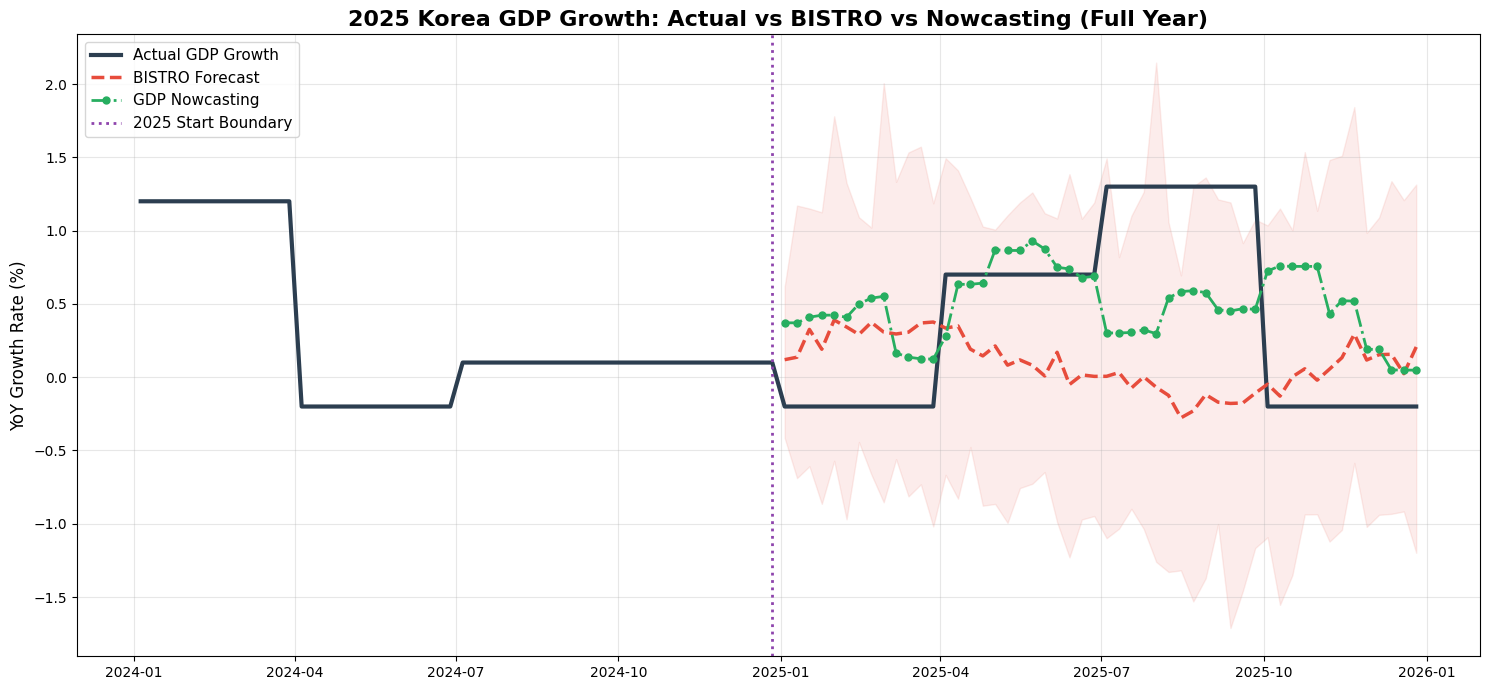

In [31]:
import os
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from gluonts.dataset.pandas import PandasDataset
from gluonts.dataset.split import split

# ==============================================================================
# [설정] BISTRO(Moirai) 환경 경로
# ==============================================================================
bistro_src_path = '/content/bistro/src'
if os.path.exists(bistro_src_path) and bistro_src_path not in sys.path:
    sys.path.insert(0, bistro_src_path)
from uni2ts.model.moirai import MoiraiForecast, MoiraiModule

# ==============================================================================
# Step 1. 기준 데이터(vintage.csv) 로드 및 주간(금요일) 전처리
# ==============================================================================
df_vintage = pd.read_csv('/content/vintage.csv', index_col='Date', parse_dates=True)

# 1-1. 타겟(GDP): W-FRI(금요일) 기준으로 맞추고 분기 값 유지
df_target = df_vintage[['N_gdp']].dropna()
df_yoy = df_target.resample('W-FRI').bfill().ffill()
df_yoy.columns = ['target']

# 1-2. 공변량(산업생산지수): W-FRI(금요일) 기준 선형 보간 및 52주 YoY
df_cov = df_vintage[['S_mf']].resample('M').last().ffill()
df_cov_weekly = df_cov.resample('W-FRI').interpolate(method='linear')
df_cov_weekly = df_cov_weekly.pct_change(52, fill_method=None) * 100
df_cov_weekly.columns = ['past_dynamic_real']

# 1-3. 병합 및 정규화
df_final = df_yoy.merge(df_cov_weekly, left_index=True, right_index=True, how='inner')
df_final = df_final.replace([np.inf, -np.inf], np.nan).dropna()

scaler = StandardScaler()
df_final['past_dynamic_real'] = scaler.fit_transform(df_final[['past_dynamic_real']])

# ==============================================================================
# Step 2. BISTRO 텐서 객체 생성 (금요일 기준)
# ==============================================================================
df_final_reset = df_final.reset_index()
df_final_reset.rename(columns={'index': 'Date'}, inplace=True)
df_final_reset['item_id'] = 'KR_GDP_GROWTH'

ds = PandasDataset.from_long_dataframe(
    df_final_reset, item_id="item_id", target="target", timestamp="Date",
    past_feat_dynamic_real=["past_dynamic_real"], feat_dynamic_real=[], freq="W-FRI"
)

FORECAST_START_DATE = '2024-12-27'
PDT = 52; CTX = 256; PSZ = 32

split_period = pd.Period(FORECAST_START_DATE, freq='W-FRI')
train, test_template = split(ds, date=split_period)
test_data = test_template.generate_instances(
    prediction_length=PDT, windows=1, distance=PDT, max_history=CTX
)

# ==============================================================================
# Step 3. BISTRO 모델 추론
# ==============================================================================
print("⏳ [Step 3] BISTRO 모델 추론 진행 중 (매주 금요일 기준)...")
model_path = "/content/bistro/bistro-finetuned"
module = MoiraiModule.from_pretrained(model_path)

model = MoiraiForecast(
    module=module, prediction_length=PDT, context_length=CTX, patch_size=PSZ,
    num_samples=100, target_dim=1,
    feat_dynamic_real_dim=ds.num_feat_dynamic_real,
    past_feat_dynamic_real_dim=ds.num_past_feat_dynamic_real
)

with torch.no_grad():
    predictor = model.create_predictor(batch_size=32)
    forecasts = list(predictor.predict(test_data.input))

samples = np.asarray(forecasts[0].samples)
preds = np.median(samples, axis=0)
ci_lower = np.percentile(samples, 5, axis=0)
ci_upper = np.percentile(samples, 95, axis=0)

# ==============================================================================
# Step 4. ★ GDP Nowcasting 금요일 데이터 병합 (2025Q4 추가 완료!)
# ==============================================================================
def process_nowcast(file_path, q_start, q_end):
    try:
        df = pd.read_csv(file_path)
        df.columns = ['Date', 'Nowcast_GDP']
        df['Date'] = pd.to_datetime(df['Date'])
        # 분기 경계를 벗어나는 추정치 엄격히 삭제
        df = df[(df['Date'] >= q_start) & (df['Date'] <= q_end)].copy()
        df.set_index('Date', inplace=True)
        return df
    except Exception as e:
        print(f"⚠️ {file_path} 읽기 실패: {e}")
        return pd.DataFrame()

print("⏳ [Step 4] Nowcasting 금요일 데이터(1~4분기 전체) 병합 중...")
dfs_nowcast = [
    process_nowcast('/content/2024Q4.csv', '2024-10-01', '2024-12-31'),
    process_nowcast('/content/2025Q1.csv', '2025-01-01', '2025-03-31'),
    process_nowcast('/content/2025Q2.csv', '2025-04-01', '2025-06-30'),
    process_nowcast('/content/2025Q3.csv', '2025-07-01', '2025-09-30'),
    process_nowcast('/content/2025Q4.csv', '2025-10-01', '2025-12-31') # ★ 4분기 파일 추가
]
df_nowcast_combined = pd.concat(dfs_nowcast)

# ==============================================================================
# Step 5. 2025년 전체 평가표 및 시각화
# ==============================================================================
# 2025년 1월 첫 금요일(01-03) ~ 12월 마지막 금요일(12-26)
future_idx = pd.date_range(start=pd.to_datetime(FORECAST_START_DATE) + pd.Timedelta(days=7),
                           periods=PDT, freq='W-FRI')

df_res = pd.DataFrame({'BISTRO_Forecast': preds}, index=future_idx)
df_res['Actual_GDP'] = df_yoy['target'].loc[future_idx].values
df_res = df_res.join(df_nowcast_combined, how='left')

# 절대 오차 계산
df_res['Err_BISTRO'] = (df_res['BISTRO_Forecast'] - df_res['Actual_GDP']).abs()
df_res['Err_Nowcast'] = (df_res['Nowcast_GDP'] - df_res['Actual_GDP']).abs()

print("\n" + "="*85)
print(f"📊 2025년 1~4분기 전체 GDP 성장률 모델 성능 평가 (금요일 기준)")
print("="*85)

# 생략 없이 52주 데이터 모두 출력
pd.set_option('display.max_rows', None)
print(df_res.round(3))
pd.reset_option('display.max_rows')

# 평균 오차(MAE) 비교 출력
print("\n" + "="*40)
print("💡 [2025년 전체 평균 오차(MAE) 비교]")
print(f"- BISTRO 모델 평균 오차: {df_res['Err_BISTRO'].mean():.3f}%p")
print(f"- Nowcasting 평균 오차: {df_res['Err_Nowcast'].mean():.3f}%p")
print("="*40)

# ----------------- 그래프 시각화 -----------------
plt.figure(figsize=(15, 7))

# 1. 실제 데이터
actual_plot_end = future_idx[-1]
df_actual_plot = df_yoy.loc[:actual_plot_end]
past_plot_len = 104
plt.plot(df_actual_plot.index[-past_plot_len:], df_actual_plot['target'].iloc[-past_plot_len:],
         label='Actual GDP Growth', color='#2c3e50', linewidth=3, zorder=2)

# 2. BISTRO 예측
plt.plot(future_idx, preds, label='BISTRO Forecast',
         color='#e74c3c', marker='', linestyle='--', linewidth=2.5, zorder=3)
plt.fill_between(future_idx, ci_lower, ci_upper, color='#e74c3c', alpha=0.1, zorder=1)

# 3. Nowcasting 예측
plt.plot(df_res.index, df_res['Nowcast_GDP'], label='GDP Nowcasting',
         color='#27ae60', marker='o', linestyle='-.', linewidth=2, markersize=5, zorder=4)

plt.title("2025 Korea GDP Growth: Actual vs BISTRO vs Nowcasting (Full Year)", fontsize=16, fontweight='bold')
plt.ylabel("YoY Growth Rate (%)", fontsize=12)
plt.axvline(x=pd.to_datetime(FORECAST_START_DATE), color='#8e44ad', linestyle=':', label='2025 Start Boundary', linewidth=2)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

⏳ [Step 3] BISTRO 모델 추론 진행 중 (매주 금요일 기준)...
Loading weights from local directory
⏳ [Step 4] Nowcasting 금요일 데이터(1~4분기 전체) 병합 중...

📊 2025년 1~4분기 전체 GDP 성장률 모델 성능 평가 (금요일 기준)
            BISTRO_Forecast  Actual_GDP  Nowcast_GDP  Err_BISTRO  Err_Nowcast
2025-01-03            0.097        -0.2        0.371       0.297        0.571
2025-01-10            0.107        -0.2        0.371       0.307        0.571
2025-01-17            0.276        -0.2        0.409       0.476        0.609
2025-01-24            0.239        -0.2        0.423       0.439        0.623
2025-01-31            0.285        -0.2        0.423       0.485        0.623
2025-02-07            0.341        -0.2        0.409       0.541        0.609
2025-02-14            0.342        -0.2        0.500       0.542        0.700
2025-02-21            0.349        -0.2        0.539       0.549        0.739
2025-02-28            0.456        -0.2        0.552       0.656        0.752
2025-03-07            0.478        -0.2        

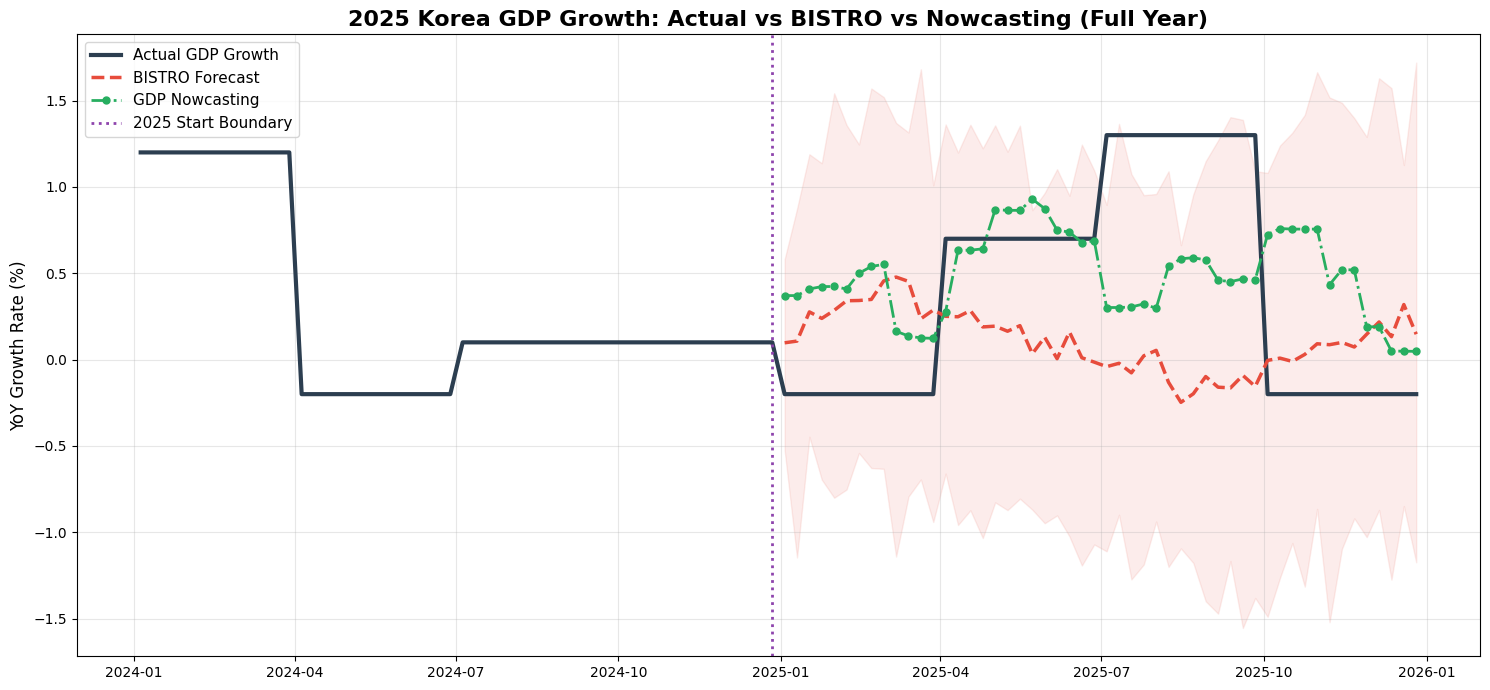

In [29]:
import os
import sys
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from gluonts.dataset.pandas import PandasDataset
from gluonts.dataset.split import split

# ==============================================================================
# [설정] BISTRO(Moirai) 환경 경로
# ==============================================================================
bistro_src_path = '/content/bistro/src'
if os.path.exists(bistro_src_path) and bistro_src_path not in sys.path:
    sys.path.insert(0, bistro_src_path)
from uni2ts.model.moirai import MoiraiForecast, MoiraiModule

# ==============================================================================
# Step 1. 기준 데이터(vintage.csv) 로드 및 주간(금요일) 전처리
# ==============================================================================
df_vintage = pd.read_csv('/content/vintage.csv', index_col='Date', parse_dates=True)

# 1-1. 타겟(GDP): W-FRI(금요일) 기준으로 맞추고 분기 값 유지
df_target = df_vintage[['N_gdp']].dropna()
df_yoy = df_target.resample('W-FRI').bfill().ffill()
df_yoy.columns = ['target']

# 1-2. 공변량(산업생산지수): W-FRI(금요일) 기준 선형 보간 및 52주 YoY
df_cov = df_vintage[['S_mf']].resample('M').last().ffill()
df_cov_weekly = df_cov.resample('W-FRI').interpolate(method='linear')
df_cov_weekly = df_cov_weekly.pct_change(52, fill_method=None) * 100
df_cov_weekly.columns = ['past_dynamic_real']

# 1-3. 병합 및 정규화
df_final = df_yoy.merge(df_cov_weekly, left_index=True, right_index=True, how='inner')
df_final = df_final.replace([np.inf, -np.inf], np.nan).dropna()

scaler = StandardScaler()
df_final['past_dynamic_real'] = scaler.fit_transform(df_final[['past_dynamic_real']])

# ==============================================================================
# Step 2. BISTRO 텐서 객체 생성 (금요일 기준)
# ==============================================================================
df_final_reset = df_final.reset_index()
df_final_reset.rename(columns={'index': 'Date'}, inplace=True)
df_final_reset['item_id'] = 'KR_GDP_GROWTH'

ds = PandasDataset.from_long_dataframe(
    df_final_reset, item_id="item_id", target="target", timestamp="Date",
    past_feat_dynamic_real=["past_dynamic_real"], feat_dynamic_real=[], freq="W-FRI"
)

FORECAST_START_DATE = '2024-12-27'
PDT = 52; CTX = 256; PSZ = 32

split_period = pd.Period(FORECAST_START_DATE, freq='W-FRI')
train, test_template = split(ds, date=split_period)
test_data = test_template.generate_instances(
    prediction_length=PDT, windows=1, distance=PDT, max_history=CTX
)

# ==============================================================================
# Step 3. BISTRO 모델 추론
# ==============================================================================
print("⏳ [Step 3] BISTRO 모델 추론 진행 중 (매주 금요일 기준)...")
model_path = "/content/bistro/bistro-finetuned"
module = MoiraiModule.from_pretrained(model_path)

model = MoiraiForecast(
    module=module, prediction_length=PDT, context_length=CTX, patch_size=PSZ,
    num_samples=100, target_dim=1,
    feat_dynamic_real_dim=ds.num_feat_dynamic_real,
    past_feat_dynamic_real_dim=ds.num_past_feat_dynamic_real
)

with torch.no_grad():
    predictor = model.create_predictor(batch_size=32)
    forecasts = list(predictor.predict(test_data.input))

samples = np.asarray(forecasts[0].samples)
preds = np.median(samples, axis=0)
ci_lower = np.percentile(samples, 5, axis=0)
ci_upper = np.percentile(samples, 95, axis=0)

# ==============================================================================
# Step 4. ★ GDP Nowcasting 금요일 데이터 병합 (2025Q4 추가 완료!)
# ==============================================================================
def process_nowcast(file_path, q_start, q_end):
    try:
        df = pd.read_csv(file_path)
        df.columns = ['Date', 'Nowcast_GDP']
        df['Date'] = pd.to_datetime(df['Date'])
        # 분기 경계를 벗어나는 추정치 엄격히 삭제
        df = df[(df['Date'] >= q_start) & (df['Date'] <= q_end)].copy()
        df.set_index('Date', inplace=True)
        return df
    except Exception as e:
        print(f"⚠️ {file_path} 읽기 실패: {e}")
        return pd.DataFrame()

print("⏳ [Step 4] Nowcasting 금요일 데이터(1~4분기 전체) 병합 중...")
dfs_nowcast = [
    process_nowcast('/content/2024Q4.csv', '2024-10-01', '2024-12-31'),
    process_nowcast('/content/2025Q1.csv', '2025-01-01', '2025-03-31'),
    process_nowcast('/content/2025Q2.csv', '2025-04-01', '2025-06-30'),
    process_nowcast('/content/2025Q3.csv', '2025-07-01', '2025-09-30'),
    process_nowcast('/content/2025Q4.csv', '2025-10-01', '2025-12-31') # ★ 4분기 파일 추가
]
df_nowcast_combined = pd.concat(dfs_nowcast)

# ==============================================================================
# Step 5. 2025년 전체 평가표 및 시각화
# ==============================================================================
# 2025년 1월 첫 금요일(01-03) ~ 12월 마지막 금요일(12-26)
future_idx = pd.date_range(start=pd.to_datetime(FORECAST_START_DATE) + pd.Timedelta(days=7),
                           periods=PDT, freq='W-FRI')

df_res = pd.DataFrame({'BISTRO_Forecast': preds}, index=future_idx)
df_res['Actual_GDP'] = df_yoy['target'].loc[future_idx].values
df_res = df_res.join(df_nowcast_combined, how='left')

# 절대 오차 계산
df_res['Err_BISTRO'] = (df_res['BISTRO_Forecast'] - df_res['Actual_GDP']).abs()
df_res['Err_Nowcast'] = (df_res['Nowcast_GDP'] - df_res['Actual_GDP']).abs()

print("\n" + "="*85)
print(f"📊 2025년 1~4분기 전체 GDP 성장률 모델 성능 평가 (금요일 기준)")
print("="*85)

# 생략 없이 52주 데이터 모두 출력
pd.set_option('display.max_rows', None)
print(df_res.round(3))
pd.reset_option('display.max_rows')

# 평균 오차(MAE) 비교 출력
print("\n" + "="*40)
print("💡 [2025년 전체 평균 오차(MAE) 비교]")
print(f"- BISTRO 모델 평균 오차: {df_res['Err_BISTRO'].mean():.3f}%p")
print(f"- Nowcasting 평균 오차: {df_res['Err_Nowcast'].mean():.3f}%p")
print("="*40)

# ----------------- 그래프 시각화 -----------------
plt.figure(figsize=(15, 7))

# 1. 실제 데이터
actual_plot_end = future_idx[-1]
df_actual_plot = df_yoy.loc[:actual_plot_end]
past_plot_len = 104
plt.plot(df_actual_plot.index[-past_plot_len:], df_actual_plot['target'].iloc[-past_plot_len:],
         label='Actual GDP Growth', color='#2c3e50', linewidth=3, zorder=2)

# 2. BISTRO 예측
plt.plot(future_idx, preds, label='BISTRO Forecast',
         color='#e74c3c', marker='', linestyle='--', linewidth=2.5, zorder=3)
plt.fill_between(future_idx, ci_lower, ci_upper, color='#e74c3c', alpha=0.1, zorder=1)

# 3. Nowcasting 예측
plt.plot(df_res.index, df_res['Nowcast_GDP'], label='GDP Nowcasting',
         color='#27ae60', marker='o', linestyle='-.', linewidth=2, markersize=5, zorder=4)

plt.title("2025 Korea GDP Growth: Actual vs BISTRO vs Nowcasting (Full Year)", fontsize=16, fontweight='bold')
plt.ylabel("YoY Growth Rate (%)", fontsize=12)
plt.axvline(x=pd.to_datetime(FORECAST_START_DATE), color='#8e44ad', linestyle=':', label='2025 Start Boundary', linewidth=2)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
# ==============================================================================
# [별도 실행] 두 모델의 성능(MAE)을 채점하고 비교하는 핵심 코드
# (주의: 이 코드는 Step 1~4가 선행되어 데이터가 준비된 상태에서 실행해야 합니다)
# ==============================================================================

# 1. 2025년 52주 치 빈 도화지(데이터프레임)를 만듭니다.
df_res = pd.DataFrame(index=future_idx)

# 2. 도화지 위에 세 가지 선수를 나란히 세웁니다.
df_res['BISTRO_Forecast'] = preds                        # 선수 1: BISTRO 예측치
df_res['Nowcast_GDP'] = df_nowcast_combined['Nowcast_GDP'] # 선수 2: 기존 나우캐스팅 예측치
df_res['Actual_GDP'] = df_yoy['target'].loc[future_idx].values # 정답지: 실제 한국은행 GDP

# 3. 채점하기: (예측값 - 실제 정답)의 차이를 구한 뒤,
#    .abs()를 붙여서 마이너스(-) 꼬리표를 떼고 순수한 '격차(오차)'만 남깁니다.
df_res['Err_BISTRO'] = (df_res['BISTRO_Forecast'] - df_res['Actual_GDP']).abs()
df_res['Err_Nowcast'] = (df_res['Nowcast_GDP'] - df_res['Actual_GDP']).abs()

# 4. 매주 엎치락뒤치락한 결과를 표로 모두 출력합니다.
print("\n" + "="*85)
print(f"📊 2025년 매주(Weekly) GDP 성장률 예측 선수별 오차 기록부")
print("="*85)
pd.set_option('display.max_rows', None) # 52주 전체가 다 보이게 설정
print(df_res.round(3))
pd.reset_option('display.max_rows')

# 5. 최종 성적표 발표: 1년(52주) 동안 쌓인 오차들의 '평균(.mean())'을 구합니다.
print("\n" + "="*45)
print("💡 [2025년 최종 성적표: 평균 오차(MAE)]")
print(f"🏆 BISTRO 모델 1년 평균 오차: {df_res['Err_BISTRO'].mean():.3f}%p")
print(f"🏆 Nowcast 모델 1년 평균 오차: {df_res['Err_Nowcast'].mean():.3f}%p")
print("="*45)
print("* 숫자가 작을수록(0에 가까울수록) 정답을 잘 맞춘 우수한 모델입니다!")


📊 2025년 매주(Weekly) GDP 성장률 예측 선수별 오차 기록부
            BISTRO_Forecast  Nowcast_GDP  Actual_GDP  Err_BISTRO  Err_Nowcast
2025-01-03            0.138        0.371        -0.2       0.338        0.571
2025-01-10            0.135        0.371        -0.2       0.335        0.571
2025-01-17            0.165        0.409        -0.2       0.365        0.609
2025-01-24            0.207        0.423        -0.2       0.407        0.623
2025-01-31            0.218        0.423        -0.2       0.418        0.623
2025-02-07            0.396        0.409        -0.2       0.596        0.609
2025-02-14            0.405        0.500        -0.2       0.605        0.700
2025-02-21            0.394        0.539        -0.2       0.594        0.739
2025-02-28            0.273        0.552        -0.2       0.473        0.752
2025-03-07            0.369        0.164        -0.2       0.569        0.364
2025-03-14            0.282        0.137        -0.2       0.482        0.337
2025-03-21            